# Лаболаторная работа № 3

____

### Изображения и видео: извлечение разметки, COCO, обучение детектора


In [73]:
!pip install opencv-python torch torchvision pycocotools matplotlib tqdm lxml

import json
import random
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import (
    FasterRCNN_MobileNet_V3_Large_FPN_Weights,
    fasterrcnn_mobilenet_v3_large_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm.auto import tqdm
from torchvision.transforms import functional as F

try:
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
except ImportError:
    COCO = COCOeval = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path(".") 
VIDEO_OUT = ROOT / "output.mp4"
VIDEO_IN = ROOT / "input.mp4"
GT_XML = ROOT / "annotations.xml"

FRAMES_DIR = ROOT / "frames"
COCO_DIR = ROOT / "coco"
EXTRACTED_VIDEO = ROOT / "extracted_bboxes.mp4"

FRAMES_DIR.mkdir(exist_ok=True)
COCO_DIR.mkdir(exist_ok=True)

### Переходим к декодированию видео

Используем OpenCV. Для обучения сохраним кадры из input.mp4 (без bbox), и извлечём разметку из output.mp4

In [74]:
def decode_video(path: Path, save_dir: Path | None = None, prefix: str = "frame"):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frames = []
    idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
        if save_dir is not None:
            cv2.imwrite(str(save_dir / f"{prefix}_{idx:04d}.jpg"), frame)
        idx += 1
    cap.release()
    meta = {"path": str(path), "fps": fps, "width": w, "height": h, "frames": idx}
    return frames, meta

# сохраняем кадры input (для датасета; ~301 файлов)
_, meta_in = decode_video(VIDEO_IN, save_dir=FRAMES_DIR, prefix="input")
_, meta_out = decode_video(VIDEO_OUT, save_dir=None)  # в память не грузим всё — ниже потоково

print("input.mp4:", meta_in)
print("output.mp4:", meta_out)

input.mp4: {'path': 'input.mp4', 'fps': 30.0, 'width': 1920, 'height': 1080, 'frames': 301}
output.mp4: {'path': 'output.mp4', 'fps': 30.0, 'width': 1920, 'height': 1080, 'frames': 301}


### Парсинг эталонной разметки (CVAT XML)

из annotations.xml получаем словарь 'номер кадра -> список bbox' и класс: car, minivan с цветами разметки,
кстати, просмотрев annotations, можно заметить 305 кадр, значит annotations размечалось по большему видео

In [75]:
def load_gt_cvat(xml_path: Path) -> tuple[dict[int, list], dict[str, str]]:
    """frame_id -> [(label, [x1,y1,x2,y2]), ...]; label -> hex color."""
    tree = ET.parse(xml_path)
    label_colors = {}
    for label in tree.findall(".//label"):
        name = label.find("name").text
        color = label.find("color").text
        label_colors[name] = color

    gt = defaultdict(list)
    for track in tree.findall("track"):
        label = track.get("label")
        for box in track.findall("box"):
            if box.get("outside") == "1":
                continue
            frame_id = int(box.get("frame"))
            bbox = [
                float(box.get("xtl")),
                float(box.get("ytl")),
                float(box.get("xbr")),
                float(box.get("ybr")),
            ]
            gt[frame_id].append((label, bbox))
    return dict(gt), label_colors

GT_BY_FRAME, LABEL_COLORS = load_gt_cvat(GT_XML)
n_boxes = sum(len(v) for v in GT_BY_FRAME.values())
print(f"Классов: {list(LABEL_COLORS.keys())}")
print(f"Кадров с разметкой: {len(GT_BY_FRAME)}, всего bbox: {n_boxes}")
print("Пример кадра 100:", GT_BY_FRAME.get(100, [])[:2])

Классов: ['car', 'minivan']
Кадров с разметкой: 901, всего bbox: 9659
Пример кадра 100: [('car', [613.57, 79.46, 654.8, 120.4]), ('car', [603.0, 48.9, 639.4, 83.8])]



### Вспомогательные функции: IoU, матчинг, контуры

In [76]:
def box_iou(a, b) -> float:
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def match_boxes(pred_boxes, gt_boxes, iou_thr=0.5):
    """Жадное сопоставление pred с gt по IoU"""
    used = set()
    matched_ious = []
    for p in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gt_boxes):
            if j in used:
                continue
            iou = box_iou(p, g)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_j >= 0 and best_iou >= iou_thr:
            used.add(best_j)
            matched_ious.append(best_iou)
    recall = len(matched_ious) / len(gt_boxes) if gt_boxes else 0.0
    return matched_ious, recall


def mask_to_boxes(mask: np.ndarray, min_area: int = 120) -> list[list[float]]:
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h >= min_area:
            boxes.append([float(x), float(y), float(x + w), float(y + h)])
    return boxes


def classify_bbox_category(
    inp: np.ndarray,
    out: np.ndarray,
    box: list[float],
    diff_thr: int = 12,
) -> int:
    """Определяет класс по цвету рамки на output (car=1, minivan=2).

    В CVAT: car #2a00ff (Hue ~112), minivan #b725ff (Hue ~62).
    Смотрим только пиксели, где input и output отличаются (сама разметка).
    """
    x1, y1, x2, y2 = map(int, box)
    h_img, w_img = out.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)
    if x2 <= x1 or y2 <= y1:
        return 1

    diff_gray = cv2.cvtColor(cv2.absdiff(inp, out), cv2.COLOR_BGR2GRAY)
    overlay = diff_gray[y1:y2, x1:x2] > diff_thr
    hue = cv2.cvtColor(out[y1:y2, x1:x2], cv2.COLOR_BGR2HSV)[:, :, 0][overlay]

    if hue.size == 0:
        return 1

    minivan_votes = int(((hue >= 45) & (hue <= 85)).sum())
    car_votes = int(((hue >= 95) & (hue <= 130)).sum())

    return 2 if minivan_votes > car_votes else 1

### Три метода извлечения bbox

In [77]:
def extract_diff(inp: np.ndarray, out: np.ndarray, thr: int = 12) -> list[list[float]]:
    """ выделение по разности кадров"""
    
    diff = cv2.absdiff(inp, out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, thr, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask_to_boxes(mask)


def extract_hsv(frame: np.ndarray) -> list[list[float]]:
    """выделение по цвету"""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask1 = cv2.inRange(hsv, np.array([115, 40, 80]), np.array([145, 255, 255]))
    mask2 = cv2.inRange(hsv, np.array([140, 30, 80]), np.array([175, 255, 255]))
    mask = cv2.bitwise_or(mask1, mask2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask_to_boxes(mask)


def extract_canny_diff(inp: np.ndarray, out: np.ndarray) -> list[list[float]]:
    """выделение по границам разности"""
    diff = cv2.absdiff(inp, out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 30, 100)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    dil = cv2.dilate(edges, kernel, iterations=2)
    closed = cv2.morphologyEx(dil, cv2.MORPH_CLOSE, kernel, iterations=3)
    return mask_to_boxes(closed, min_area=150)


EXTRACTORS = {
    "diff": lambda inp, out: extract_diff(inp, out),
    "hsv": lambda inp, out: extract_hsv(out),
    "canny_diff": lambda inp, out: extract_canny_diff(inp, out),
}


| Метод | Идея | Плюсы | Минусы |
|-------|------|-------|--------|
| **diff** | Сравнивает два кадра, убирает шум, находит контуры | Находит любые движущиеся объекты, не важно какого цвета | Склеивает объекты, если они близко; ошибается из-за сжатия видео |
| **hsv** | `Ищет пиксели сине-фиолетового цвета в цветовой модели HSV | НРаботает с одним кадром (не нужны два кадра)| Пропускает объекты с размытыми краями |
| **canny_diff** | Ищет границы объектов на разнице двух кадров | Выше IoU у найденных | Находит меньше объектов, чем diff |


### Сравнительный анализ по всему видео

для каждого кадра читаем пару из inрut и output и прогоняем их по нашим методам

In [78]:
def evaluate_extractor(name: str, iou_thr: float = 0.5):
    cap_in = cv2.VideoCapture(str(VIDEO_IN))
    cap_out = cv2.VideoCapture(str(VIDEO_OUT))
    fn = EXTRACTORS[name]

    all_ious, recalls = [], []
    total_gt = 0

    for frame_id in tqdm(range(int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))), desc=name):
        ok1, inp = cap_in.read()
        ok2, out = cap_out.read()
        if not (ok1 and ok2):
            break
        gt_boxes = [b for _, b in GT_BY_FRAME.get(frame_id, [])]
        if not gt_boxes:
            continue
        pred_boxes = fn(inp, out)
        matched, rec = match_boxes(pred_boxes, gt_boxes, iou_thr)
        all_ious.extend(matched)
        recalls.append(rec)
        total_gt += len(gt_boxes)

    cap_in.release()
    cap_out.release()
    return {
        "method": name,
        "mean_iou_matched": float(np.mean(all_ious)) if all_ious else 0.0,
        "mean_recall": float(np.mean(recalls)) if recalls else 0.0,
        "matched_pairs": len(all_ious),
        "gt_boxes": total_gt,
    }

comparison = [evaluate_extractor(m) for m in EXTRACTORS]
for row in comparison:
    print(row)

diff:   0%|          | 0/301 [00:00<?, ?it/s]

hsv:   0%|          | 0/301 [00:00<?, ?it/s]

canny_diff:   0%|          | 0/301 [00:00<?, ?it/s]

{'method': 'diff', 'mean_iou_matched': 0.6660094291116879, 'mean_recall': 0.4938325517229172, 'matched_pairs': 1741, 'gt_boxes': 3647}
{'method': 'hsv', 'mean_iou_matched': 0.6437588441114563, 'mean_recall': 0.11590695203652016, 'matched_pairs': 429, 'gt_boxes': 3647}
{'method': 'canny_diff', 'mean_iou_matched': 0.6781701737023287, 'mean_recall': 0.26427336967204074, 'matched_pairs': 909, 'gt_boxes': 3647}


Вывод по сравнению:

 `diff` даёт  около 49% recall при среднем IoU 0.67 у совпавших пар — разумный 

#### Ну и визуальный результат сравнения

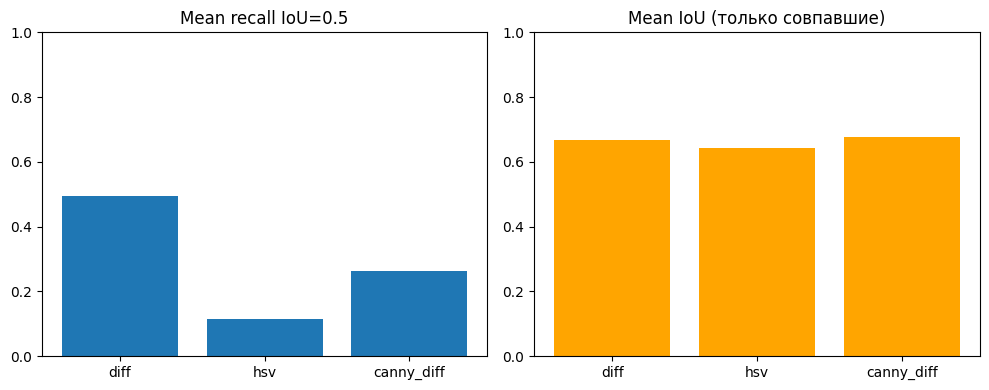

In [79]:
names = [r["method"] for r in comparison]
recalls = [r["mean_recall"] for r in comparison]
ious = [r["mean_iou_matched"] for r in comparison]

# на сколько метод не пропускает обьекты
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(names, recalls)
ax[0].set_title("Mean recall IoU=0.5")
ax[0].set_ylim(0, 1)

# на сколько правильно опеделена граница
ax[1].bar(names, ious, color="orange")
ax[1].set_title("Mean IoU (только совпавшие)")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Извлечение «лучшим» методом + визуализация одного кадра 

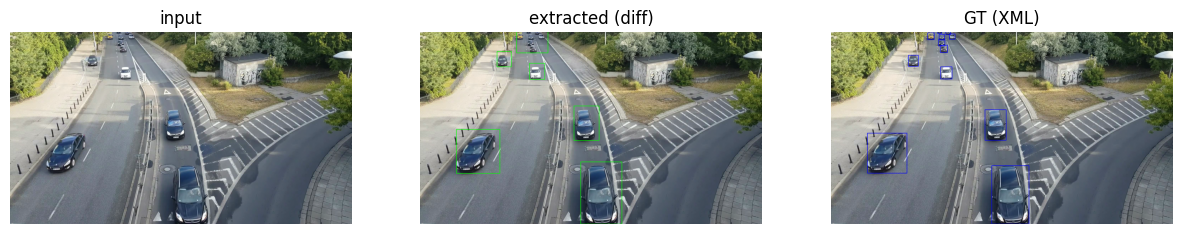

In [80]:
BEST_METHOD = "diff"

def extract_frame_boxes(frame_id: int) -> list[list[float]]:
    cap_in = cv2.VideoCapture(str(VIDEO_IN))
    cap_out = cv2.VideoCapture(str(VIDEO_OUT))
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    _, inp = cap_in.read()
    _, out = cap_out.read()
    cap_in.release()
    cap_out.release()
    return EXTRACTORS[BEST_METHOD](inp, out)

def draw_boxes(img, boxes, color=(0, 255, 0), thickness=2):
    vis = img.copy()
    for x1, y1, x2, y2 in boxes:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), color, thickness)
    return vis

fid = 100
cap = cv2.VideoCapture(str(VIDEO_IN))
cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
_, frame = cap.read()
cap.release()

pred = extract_frame_boxes(fid)
gt = [b for _, b in GT_BY_FRAME.get(fid, [])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, title in zip(
    axes,
    [frame, draw_boxes(frame, pred, (0, 255, 0)), draw_boxes(frame, gt, (255, 0, 0))],
    ["input", f"extracted ({BEST_METHOD})", "GT (XML)"],
):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.show()

### Экспорт COCO

теперь нашу разметку необходимо сохранить в формаме сосо, так как он стандартный для моделей. 

In [81]:
CATEGORIES = [
    {"id": 1, "name": "car", "supercategory": "vehicle"},
    {"id": 2, "name": "minivan", "supercategory": "vehicle"},
]
NAME_TO_ID = {c["name"]: c["id"] for c in CATEGORIES}


def build_coco_from_video(method: str = "diff") -> dict:
    cap_in = cv2.VideoCapture(str(VIDEO_IN))
    cap_out = cv2.VideoCapture(str(VIDEO_OUT))
    fn = EXTRACTORS[method]

    coco = {
        "info": {"description": "extracted from output.mp4", "version": "1.0"},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": CATEGORIES,
    }
    ann_id = 1

    n_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
    for frame_id in tqdm(range(n_frames), desc="COCO"):
        ok1, inp = cap_in.read()
        ok2, out = cap_out.read()
        if not (ok1 and ok2):
            break

        h, w = inp.shape[:2]
        image_id = frame_id + 1
        file_name = f"input_{frame_id:04d}.jpg"
        coco["images"].append(
            {"id": image_id, "file_name": file_name, "width": w, "height": h, "frame_id": frame_id}
        )

        for x1, y1, x2, y2 in fn(inp, out):
            bw, bh = x2 - x1, y2 - y1
            if bw < 5 or bh < 5:
                continue
            category_id = classify_bbox_category(inp, out, [x1, y1, x2, y2])
            coco["annotations"].append(
                {
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "bbox": [round(x1, 2), round(y1, 2), round(bw, 2), round(bh, 2)],
                    "area": float(bw * bh),
                    "iscrowd": 0,
                }
            )
            ann_id += 1

    cap_in.release()
    cap_out.release()
    return coco

coco_extracted = build_coco_from_video(BEST_METHOD)
coco_path = COCO_DIR / "instances_extracted.json"
with open(coco_path, "w", encoding="utf-8") as f:
    json.dump(coco_extracted, f, ensure_ascii=False, indent=2)

from collections import Counter

class_counts = Counter(a["category_id"] for a in coco_extracted["annotations"])
print(f"images: {len(coco_extracted['images'])}, annotations: {len(coco_extracted['annotations'])}")
print("классы в COCO:", {c["name"]: class_counts.get(c["id"], 0) for c in CATEGORIES})
print(f"saved: {coco_path}")

COCO:   0%|          | 0/301 [00:00<?, ?it/s]

images: 301, annotations: 2657
классы в COCO: {'car': 1664, 'minivan': 993}
saved: coco/instances_extracted.json


### Видео с извлечённой разметкой на input.mp4

In [82]:
def render_extracted_video(out_path: Path, method: str = "diff"):
    cap_in = cv2.VideoCapture(str(VIDEO_IN))
    cap_out = cv2.VideoCapture(str(VIDEO_OUT))
    fn = EXTRACTORS[method]

    fps = cap_in.get(cv2.CAP_PROP_FPS)
    w, h = int(cap_in.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap_in.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(
        str(out_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h),
    )

    while True:
        ok1, inp = cap_in.read()
        ok2, out = cap_out.read()
        if not (ok1 and ok2):
            break
        vis = inp.copy()
        for x1, y1, x2, y2 in fn(inp, out):
            cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(vis, "extracted", (int(x1), max(0, int(y1) - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        writer.write(vis)

    cap_in.release()
    cap_out.release()
    writer.release()
    print("saved", out_path)

render_extracted_video(EXTRACTED_VIDEO, BEST_METHOD)

saved extracted_bboxes.mp4


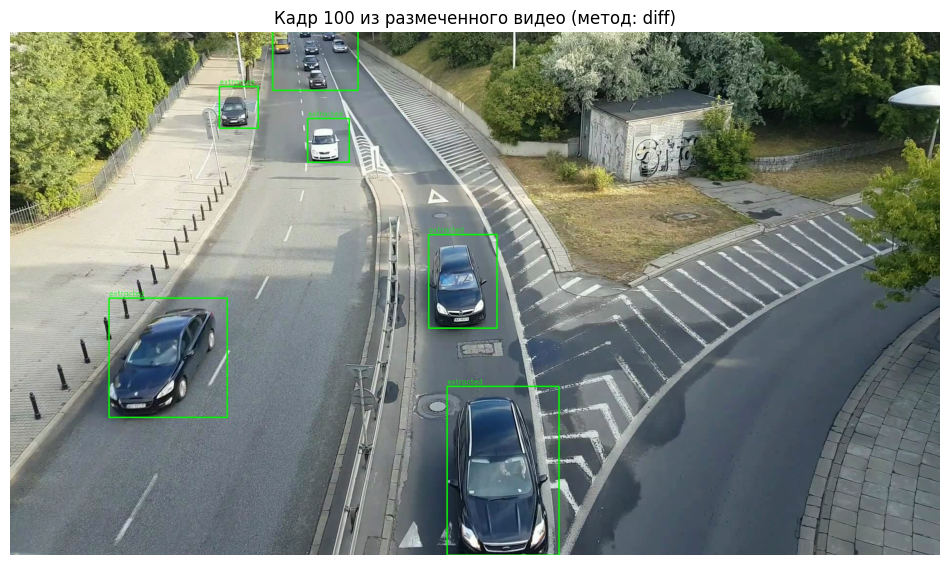

In [83]:
def show_frame_from_video(video_path: Path, frame_id: int):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    
    ok, frame = cap.read()
    if not ok:
        print(f"Не удалось прочитать кадр {frame_id}")
        cap.release()
        return
    
    # Конвертируем BGR в RGB для matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Кадр {frame_id} из размеченного видео (метод: {BEST_METHOD})")
    plt.axis('off')
    plt.show()
    
    cap.release()

show_frame_from_video(EXTRACTED_VIDEO, frame_id=100)


###  Обучим детектор и измерим mAP (среднюю точность)

разбиваем данные

In [87]:
def train_test_split_image_ids(coco_dict, val_ratio=0.2, seed=42):
    ids = [im["id"] for im in coco_dict["images"]]
    rng = random.Random(seed)
    rng.shuffle(ids)
    n_val = int(len(ids) * val_ratio)
    val_set = set(ids[:n_val])
    train = [i for i in ids if i not in val_set]
    val = [i for i in ids if i in val_set]
    return train, val

переходим к обучению модели, у меня это  MobileNetV3

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

TRAIN_MAX_SIZE = 640
FRAME_STRIDE = 2
FREEZE_BACKBONE = True
BATCH_SIZE = 4 if device.type == "cuda" else 2

train_ids, val_ids = train_test_split_image_ids(coco_extracted, val_ratio=0.2, seed=SEED)
train_ids = sorted(train_ids)[::FRAME_STRIDE]
val_ids = sorted(val_ids)[::FRAME_STRIDE]
print(f"кадров train/val: {len(train_ids)} / {len(val_ids)}, max_size={TRAIN_MAX_SIZE}")


def resize_img_and_boxes(img: torch.Tensor, boxes: torch.Tensor, max_size: int):
    _, h, w = img.shape
    scale = min(max_size / h, max_size / w, 1.0)
    if scale >= 1.0:
        return img, boxes
    new_h, new_w = int(h * scale), int(w * scale)
    img = F.resize(img, [new_h, new_w])
    if boxes.numel() > 0:
        boxes = boxes * scale
    return img, boxes


class CocoDetDataset(Dataset):
    def __init__(self, coco_dict, images_dir: Path, image_ids: list[int], max_size: int = 640):
        self.coco = coco_dict
        self.images_dir = images_dir
        self.image_ids = image_ids
        self.max_size = max_size
        self.id_to_fname = {im["id"]: im["file_name"] for im in coco_dict["images"]}
        anns_by_img = defaultdict(list)
        for ann in coco_dict["annotations"]:
            anns_by_img[ann["image_id"]].append(ann)
        self.anns_by_img = anns_by_img

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        path = self.images_dir / self.id_to_fname[image_id]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = F.to_tensor(img)

        boxes, labels = [], []
        for ann in self.anns_by_img[image_id]:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        img, boxes = resize_img_and_boxes(img, boxes, self.max_size)

        target = {
            "boxes": boxes,
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([image_id]),
        }
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


def get_model(num_classes: int = 3, freeze_backbone: bool = True):
    weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
    model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False
    return model


train_ds = CocoDetDataset(coco_extracted, FRAMES_DIR, train_ids, max_size=TRAIN_MAX_SIZE)
val_ds = CocoDetDataset(coco_extracted, FRAMES_DIR, val_ids, max_size=TRAIN_MAX_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0
)

model = get_model(num_classes=3, freeze_backbone=FREEZE_BACKBONE).to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=1e-3, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

MODEL_CKPT = COCO_DIR / "fasterrcnn_mobilenet_best.pth"
print("модель: Faster R-CNN MobileNetV3")
print("чекпоинт:", MODEL_CKPT)

device: cpu
кадров train/val: 121 / 30, max_size=640
модель: Faster R-CNN MobileNetV3
чекпоинт: coco/fasterrcnn_mobilenet_best.pth


train 1:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 1: train_loss=0.9473, val_loss=0.7277
  saved -> coco/fasterrcnn_mobilenet_best.pth


train 2:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 2: train_loss=0.5917, val_loss=0.5771
  saved -> coco/fasterrcnn_mobilenet_best.pth


train 3:   0%|          | 0/61 [00:00<?, ?it/s]

...

epoch 4: train_loss=0.4180, val_loss=0.4665
  saved -> coco/fasterrcnn_mobilenet_best.pth


train 5:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 5: train_loss=0.3999, val_loss=0.4590
  saved -> coco/fasterrcnn_mobilenet_best.pth


train 6:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 6: train_loss=0.3748, val_loss=0.4548
  saved -> coco/fasterrcnn_mobilenet_best.pth


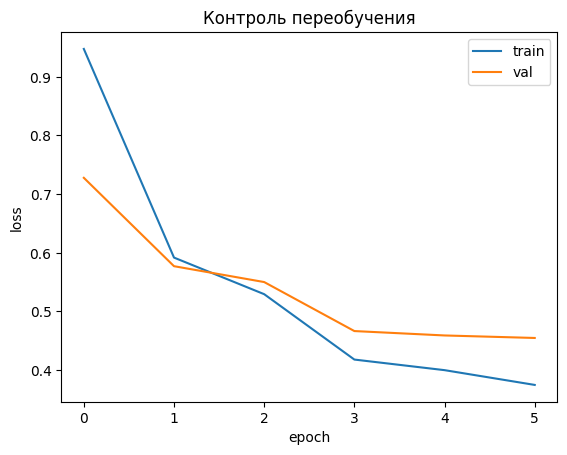

In [89]:
EPOCHS = 6
PATIENCE = 2
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"train {epoch+1}"):
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.train()  # не eval() — иначе loss не посчитается
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [im.to(device) for im in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            val_loss += sum(loss_dict.values()).item()

    train_loss /= max(len(train_loader), 1)
    val_loss /= max(len(val_loader), 1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    lr_scheduler.step()

    print(f"epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_CKPT)
        print("  saved ->", MODEL_CKPT)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Контроль переобучения")
plt.show()

Ага, на графике мы видим переобучение после 3 эпохи train и val начали расходиться

#### Теперь проверим качество модели

Сравним то, что разметила модель с тем, что мы размечали и храним в сосо

In [93]:
import copy


def scale_coco_to_train_size(coco_dict: dict, max_size: int = TRAIN_MAX_SIZE) -> dict:
    coco_s = copy.deepcopy(coco_dict)
    scales = {}
    for im in coco_dict["images"]:
        w, h = im["width"], im["height"]
        scales[im["id"]] = min(max_size / h, max_size / w, 1.0)

    for im in coco_s["images"]:
        s = scales[im["id"]]
        im["width"] = int(im["width"] * s)
        im["height"] = int(im["height"] * s)

    for ann in coco_s["annotations"]:
        s = scales[ann["image_id"]]
        x, y, bw, bh = ann["bbox"]
        ann["bbox"] = [x * s, y * s, bw * s, bh * s]
        ann["area"] = float(bw * bh * s * s)

    return coco_s


def predict_coco_format(model, dataset, device, score_thr=0.5):
    model.eval()
    results = []
    for img_tensor, target in DataLoader(dataset, batch_size=1, collate_fn=collate_fn):
        img = img_tensor[0].to(device)
        with torch.no_grad():
            pred = model([img])[0]
        image_id = int(target[0]["image_id"].item())
        for box, score, label in zip(pred["boxes"], pred["scores"], pred["labels"]):
            if score < score_thr:
                continue
            label = int(label)
            if label == 0:
                continue
            x1, y1, x2, y2 = box.tolist()
            results.append(
                {
                    "image_id": image_id,
                    "category_id": label,
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": float(score),
                }
            )
    return results


if not MODEL_CKPT.exists():
    raise FileNotFoundError(f"Нет {MODEL_CKPT}. Сначала ячейка обучения (EPOCHS).")

try:
    state = torch.load(MODEL_CKPT, map_location=device, weights_only=True)
except TypeError:
    state = torch.load(MODEL_CKPT, map_location=device)

model.load_state_dict(state)
print("загружены веса из", MODEL_CKPT)

preds = predict_coco_format(model, val_ds, device)
print("предсказаний:", len(preds))

val_coco_full = {
    "images": [im for im in coco_extracted["images"] if im["id"] in val_ids],
    "annotations": [a for a in coco_extracted["annotations"] if a["image_id"] in val_ids],
    "categories": CATEGORIES,
}

# GT в том же масштабе, что train/val Dataset
val_coco = scale_coco_to_train_size(val_coco_full, max_size=TRAIN_MAX_SIZE)

val_gt_path = COCO_DIR / "instances_val_gt.json"
val_pred_path = COCO_DIR / "instances_val_pred.json"

with open(val_gt_path, "w", encoding="utf-8") as f:
    json.dump(val_coco, f)
with open(val_pred_path, "w", encoding="utf-8") as f:
    json.dump(preds, f)

if COCO is not None:
    coco_gt = COCO(str(val_gt_path))
    coco_dt = coco_gt.loadRes(preds)
    ev = COCOeval(coco_gt, coco_dt, "bbox")
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    print(f"mAP@[0.5:0.95] = {ev.stats[0]:.4f}")
    print(f"mAP@0.5        = {ev.stats[1]:.4f}")

загружены веса из coco/fasterrcnn_mobilenet_best.pth
предсказаний: 307
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.693
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.839
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.746
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.630
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.716
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.779
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.223
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 

Получаем метрики

 - mAP@0.5 - 0.84 не плохо
 - mAP@[0.5:0.95] - 0.69 тоже нормально

 значит, модель правильно находит 84% объектов при мягком критерии (рамка совпала хотя бы наполовину) и даже при жёстком критерии (точное совпадение рамок) точность 69% — это высокий результат

### Визуализация предсказаний модели 

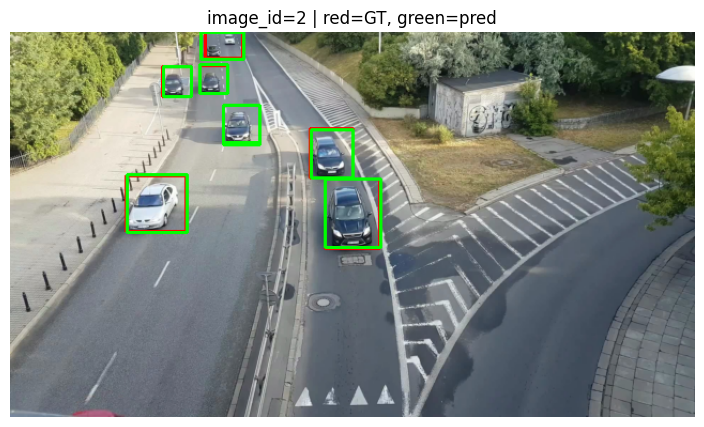

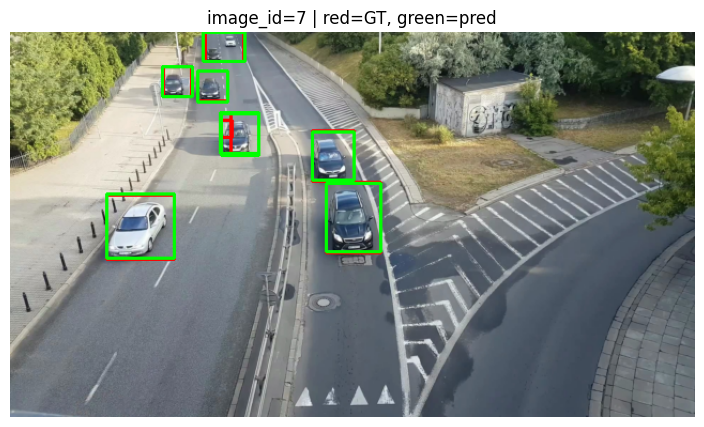

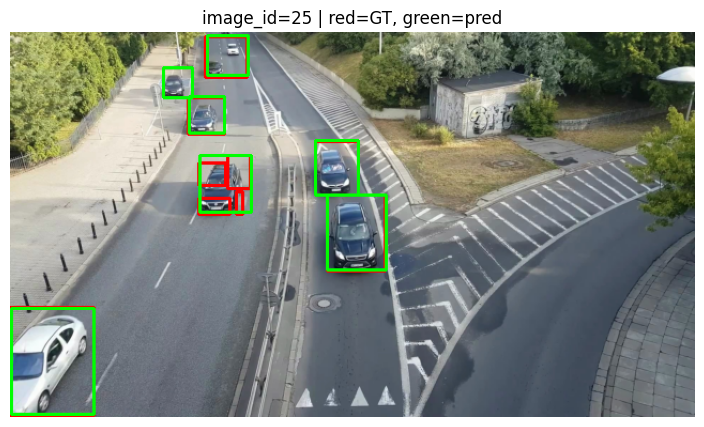

In [94]:
try:
    state = torch.load(MODEL_CKPT, map_location=device, weights_only=True)
except TypeError:
    state = torch.load(MODEL_CKPT, map_location=device)
model.load_state_dict(state)


def show_predictions(model, dataset, device, n=3, score_thr=0.5):
    model.eval()
    shown = 0
    for img, target in dataset:
        if shown >= n:
            break
        with torch.no_grad():
            pred = model([img.to(device)])[0]
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        vis = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        for box in target["boxes"]:
            x1, y1, x2, y2 = map(int, box.tolist())
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
        for box, score in zip(pred["boxes"], pred["scores"]):
            if score < score_thr:
                continue
            x1, y1, x2, y2 = map(int, box.tolist())
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        plt.figure(figsize=(10, 5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"image_id={int(target['image_id'])} | red=GT, green=pred")
        plt.axis("off")
        plt.show()
        shown += 1


show_predictions(model, val_ds, device, n=3)